In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df=pd.read_csv("HousingData.csv")

In [55]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [56]:
df.shape

(506, 14)

In [57]:
df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,int64
TAX,int64


In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [60]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [61]:
# Fill numerical columns with median
num_cols = ['CRIM', 'ZN', 'INDUS', 'AGE', 'LSTAT']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill CHAS with mode (binary feature)
df['CHAS'].fillna(df['CHAS'].mode()[0], inplace=True)

/tmp/ipykernel_1093/1984455174.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1093/1984455174.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [62]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [63]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [64]:
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
           'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (df[col] < lower) | (df[col] > upper)

    print(f"{col}: {outliers.sum()} outliers")

CRIM: 81 outliers
ZN: 126 outliers
INDUS: 0 outliers
CHAS: 34 outliers
NOX: 0 outliers
RM: 30 outliers
AGE: 0 outliers
DIS: 5 outliers
RAD: 0 outliers
TAX: 0 outliers
PTRATIO: 15 outliers
B: 77 outliers
LSTAT: 12 outliers
MEDV: 40 outliers


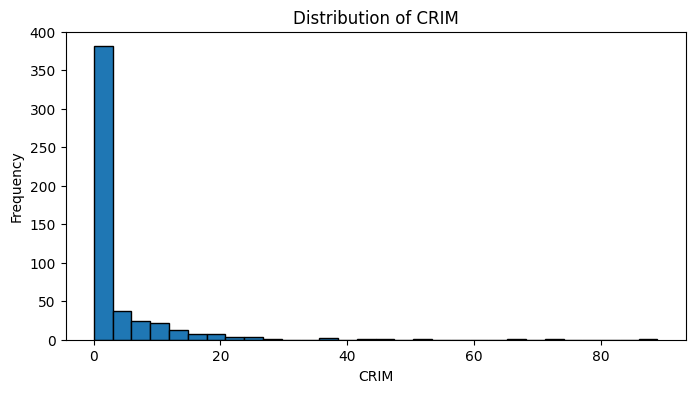

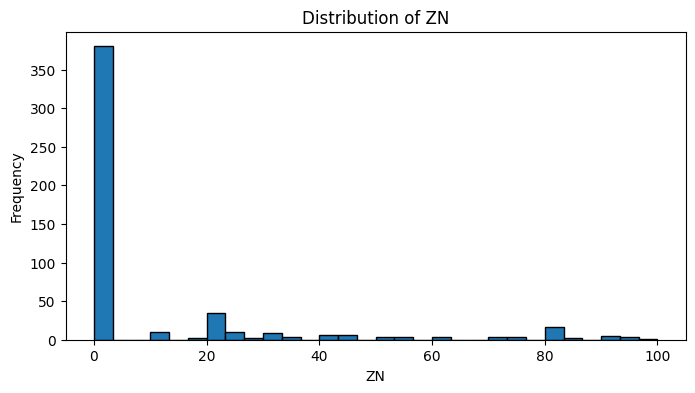

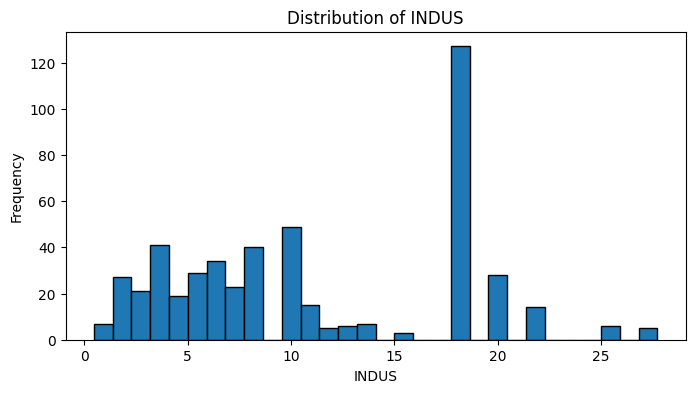

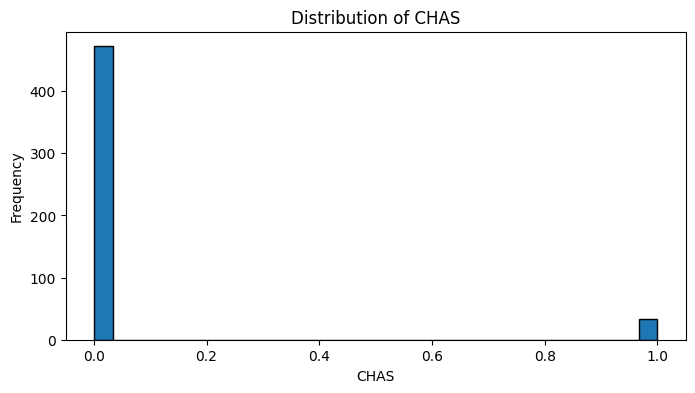

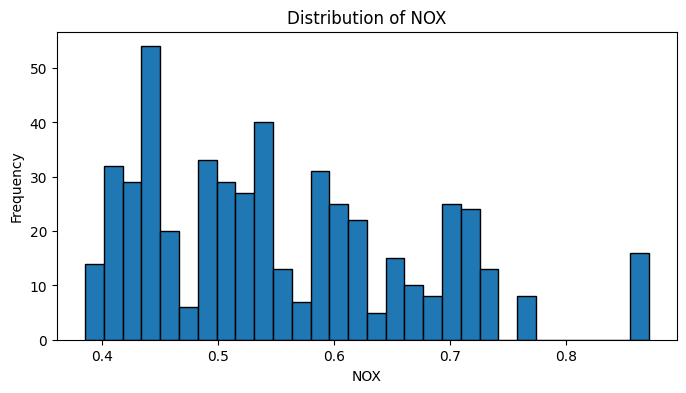

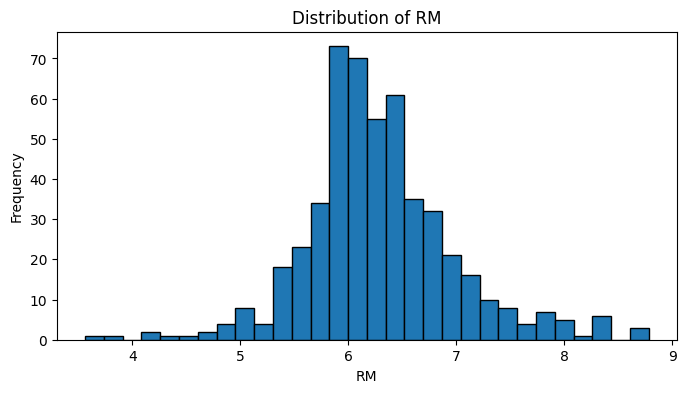

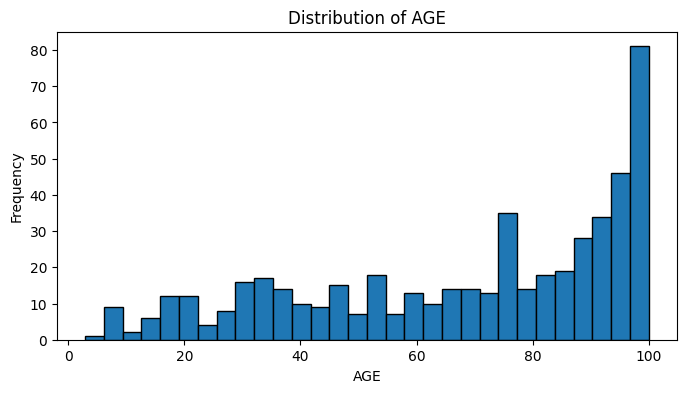

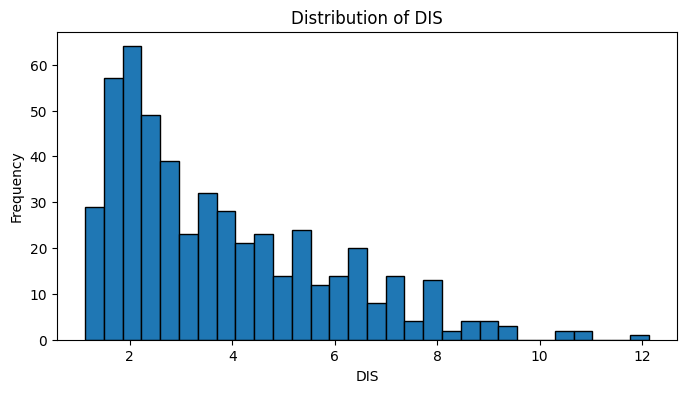

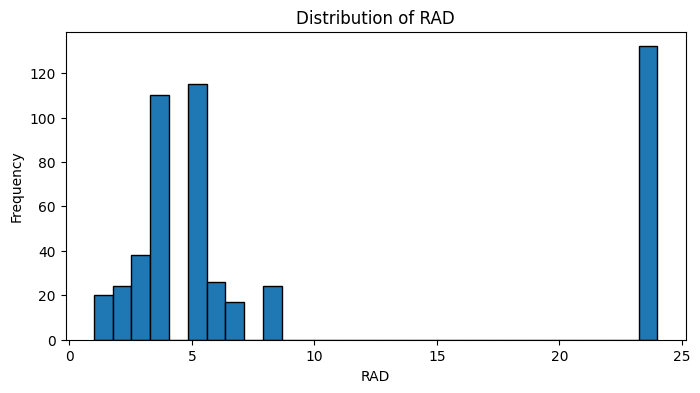

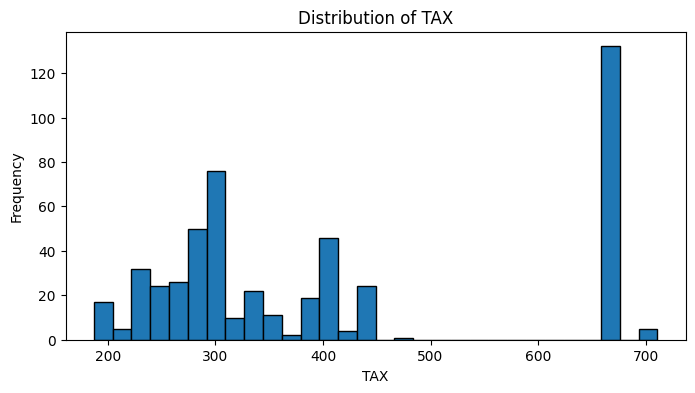

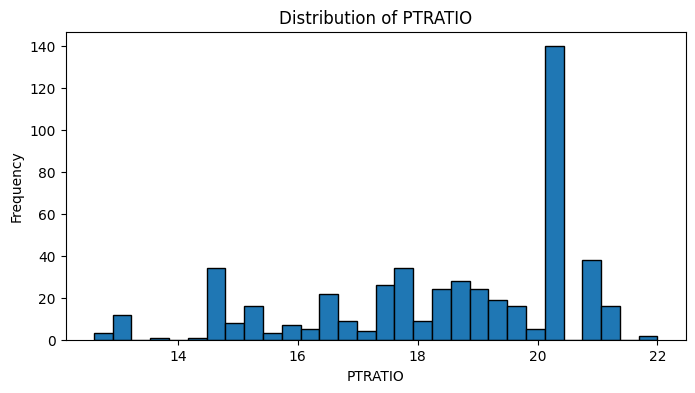

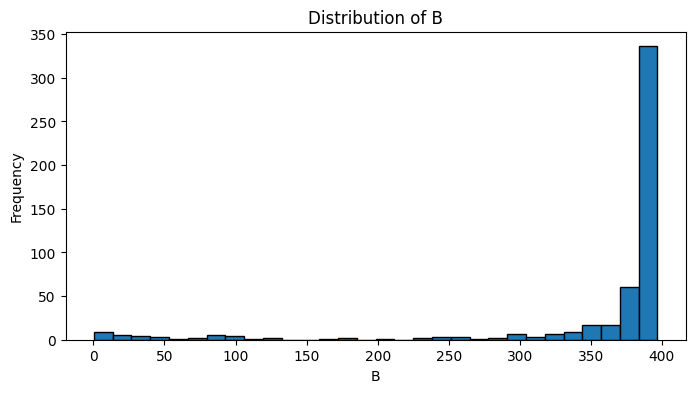

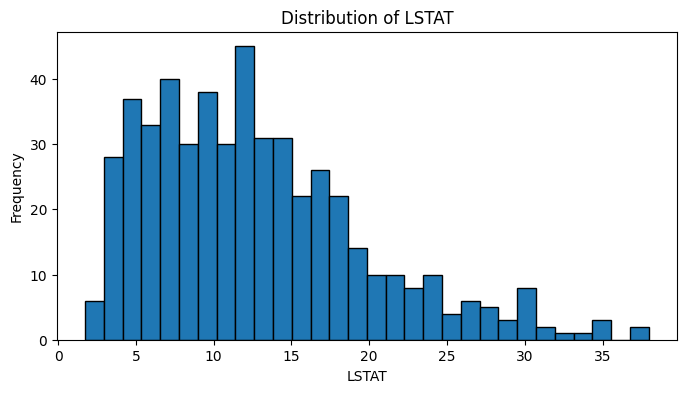

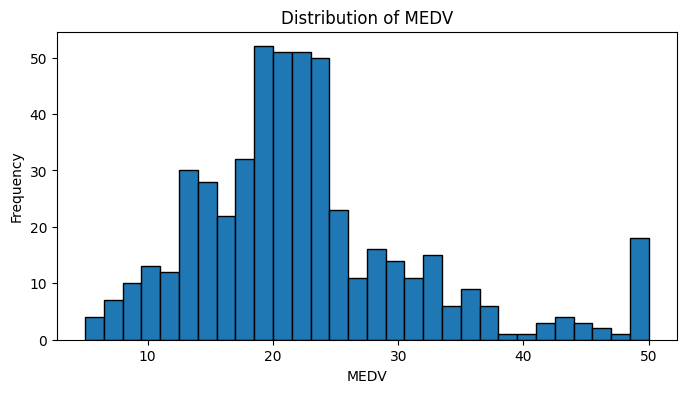

In [65]:
import matplotlib.pyplot as plt

columns = df.columns

for col in columns:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

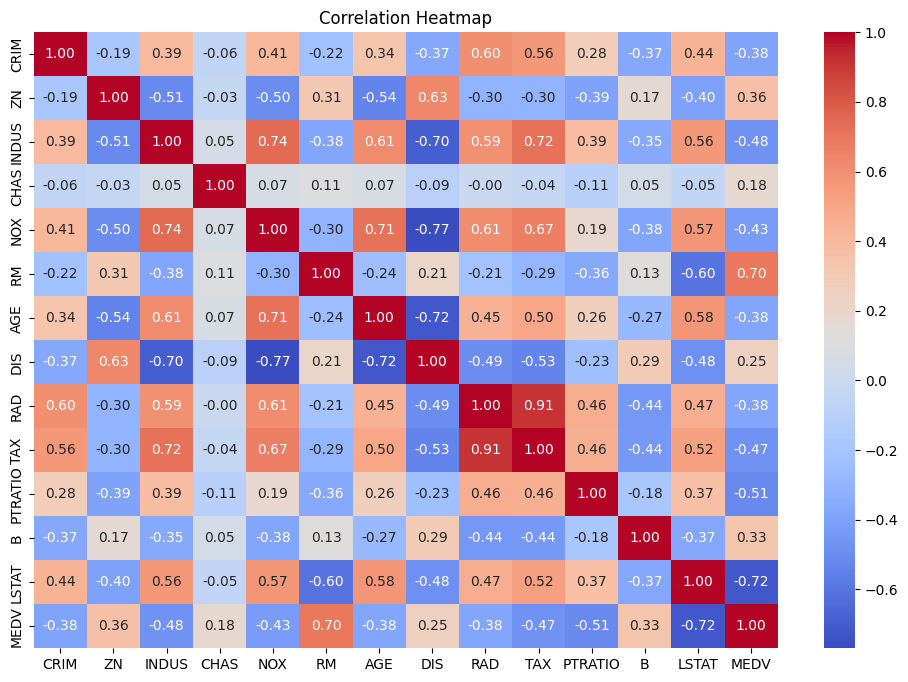

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

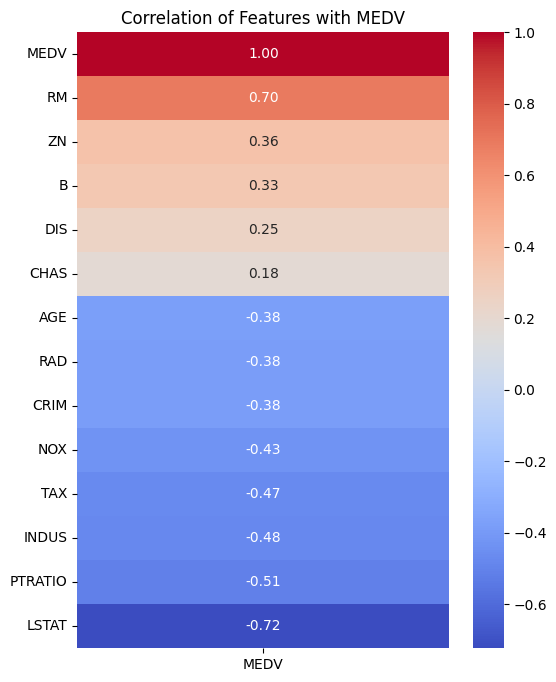

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr()[['MEDV']].sort_values(by='MEDV', ascending=False),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation of Features with MEDV")
plt.show()

In [68]:
import numpy as np

# Select only numeric columns for correlation to avoid ValueError
corr_matrix = df.select_dtypes(include=np.number).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.90]
    if not high_corr.empty:
        print(f"\n{col}")
        print(high_corr)


TAX
RAD    0.910228
Name: TAX, dtype: float64


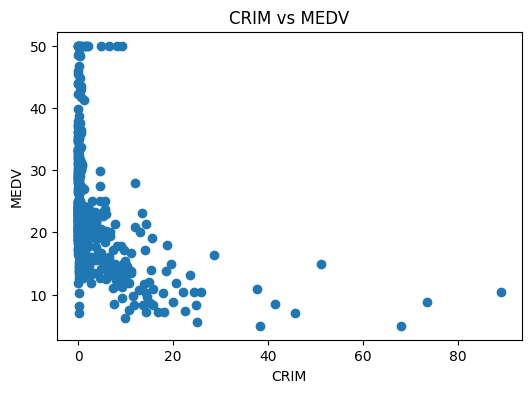

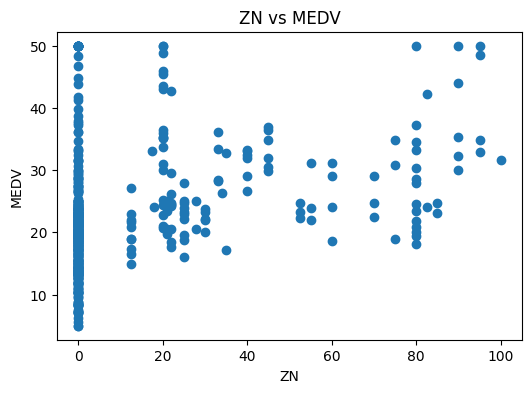

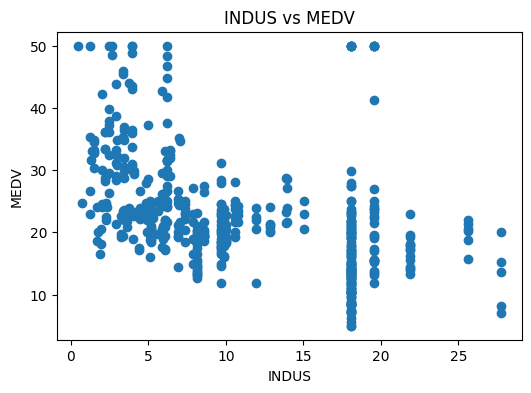

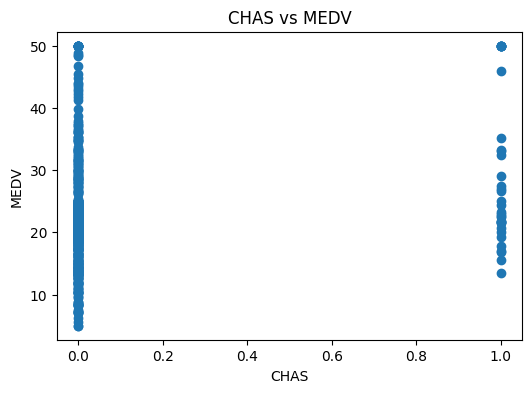

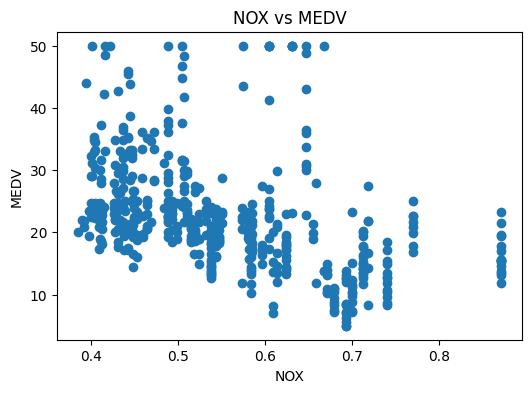

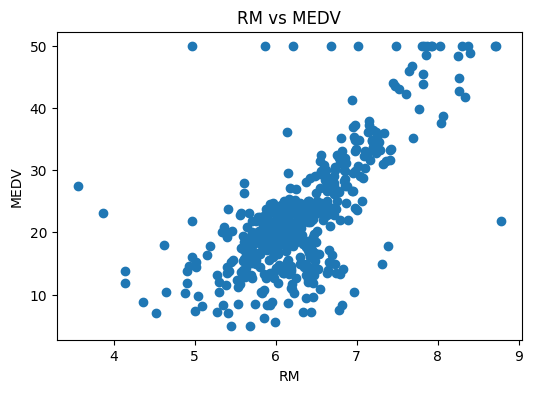

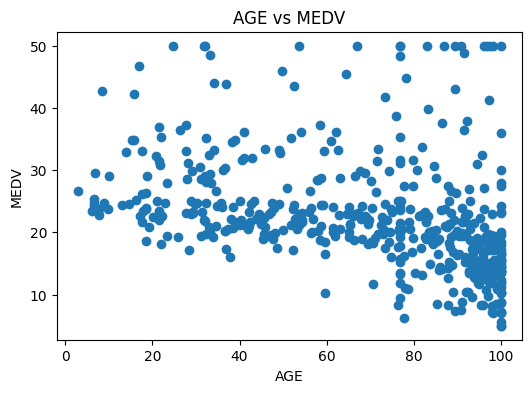

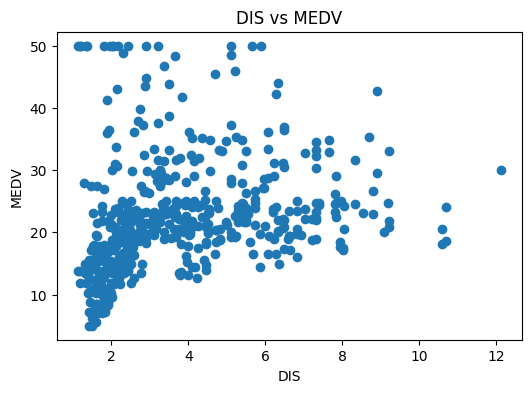

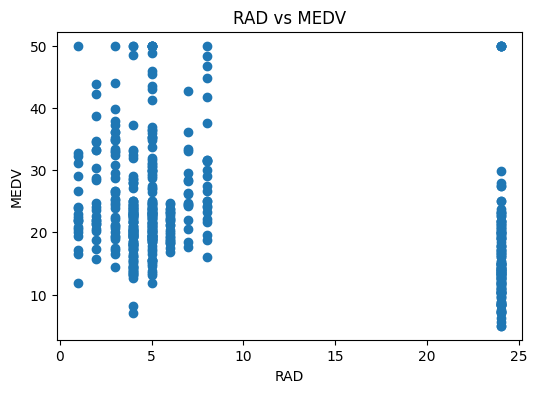

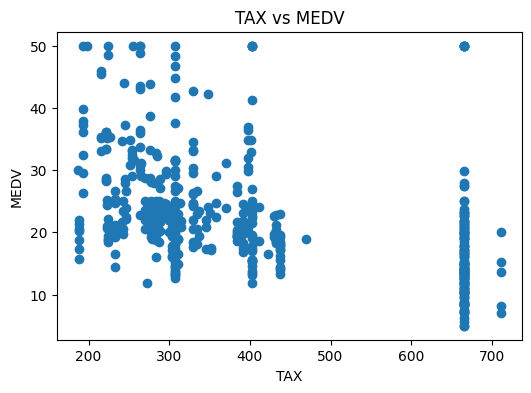

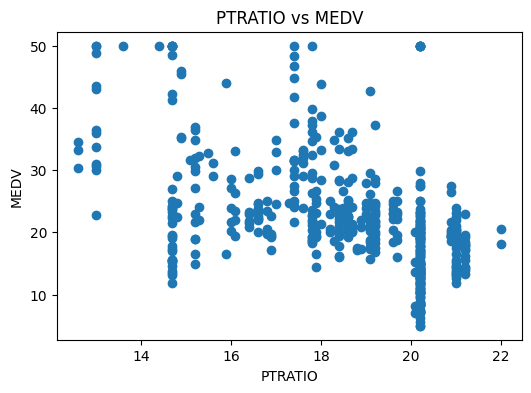

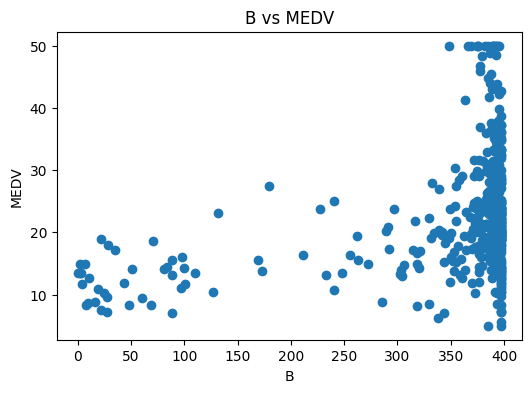

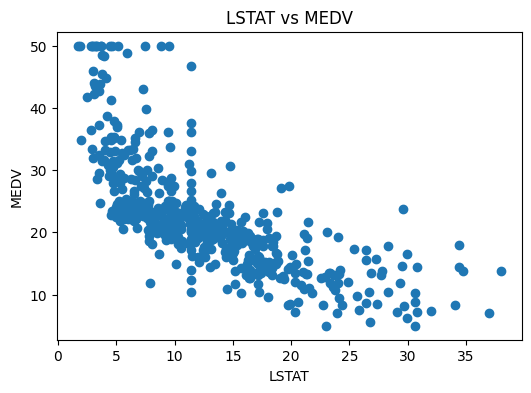

In [71]:
import matplotlib.pyplot as plt

features = df.columns.drop('MEDV')

for col in features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df['MEDV'])
    plt.xlabel(col)
    plt.ylabel("MEDV")
    plt.title(f"{col} vs MEDV")
    plt.show()

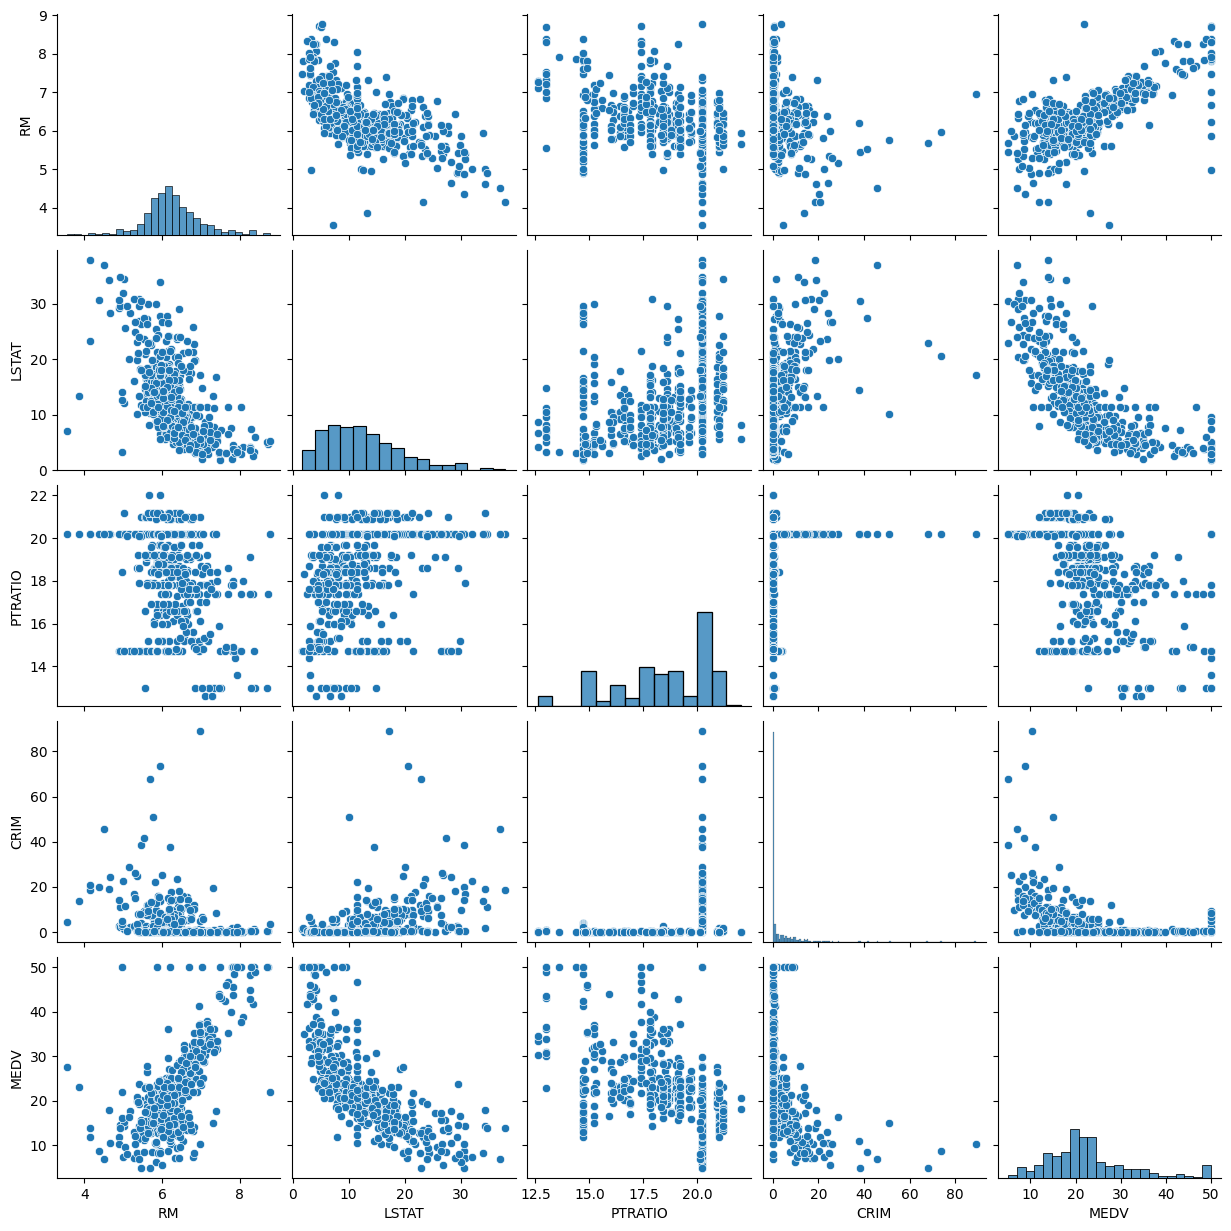

In [72]:
import seaborn as sns

sns.pairplot(df[['RM','LSTAT','PTRATIO','CRIM','MEDV']])

<Axes: >

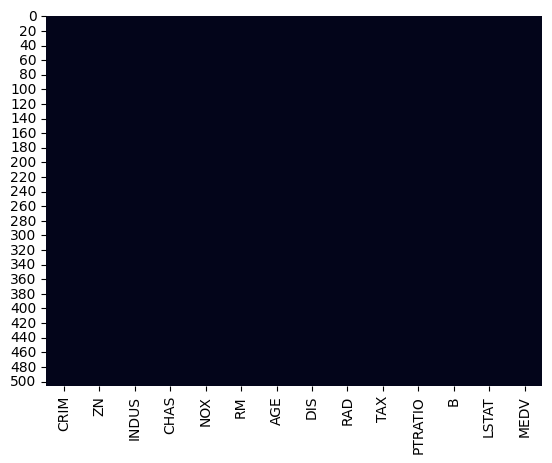

In [73]:
import seaborn as sns

sns.heatmap(df.isnull(), cbar=False)

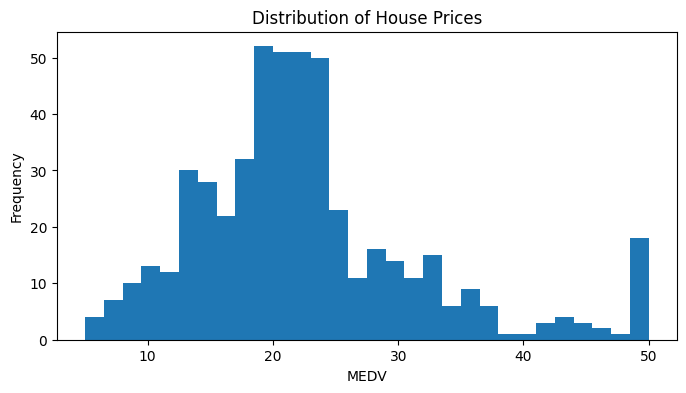

In [74]:
plt.figure(figsize=(8,4))

plt.hist(df['MEDV'], bins=30)

plt.title("Distribution of House Prices")

plt.xlabel("MEDV")

plt.ylabel("Frequency")

plt.show()

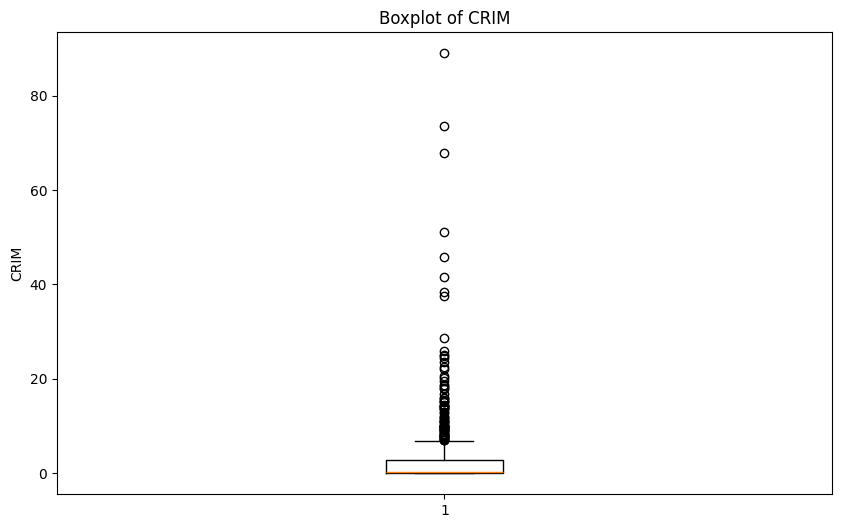

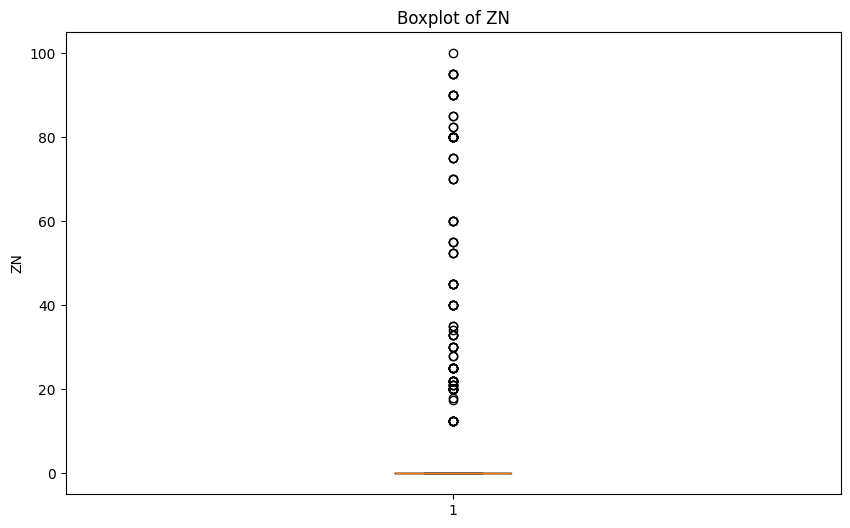

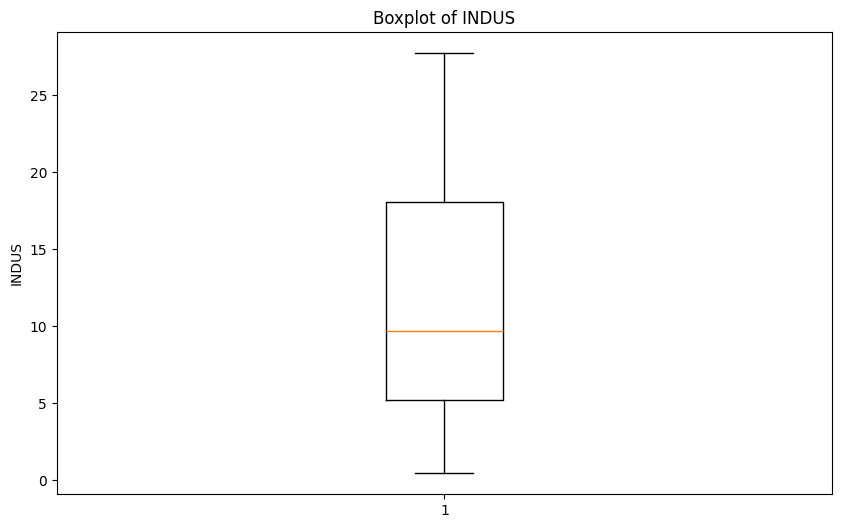

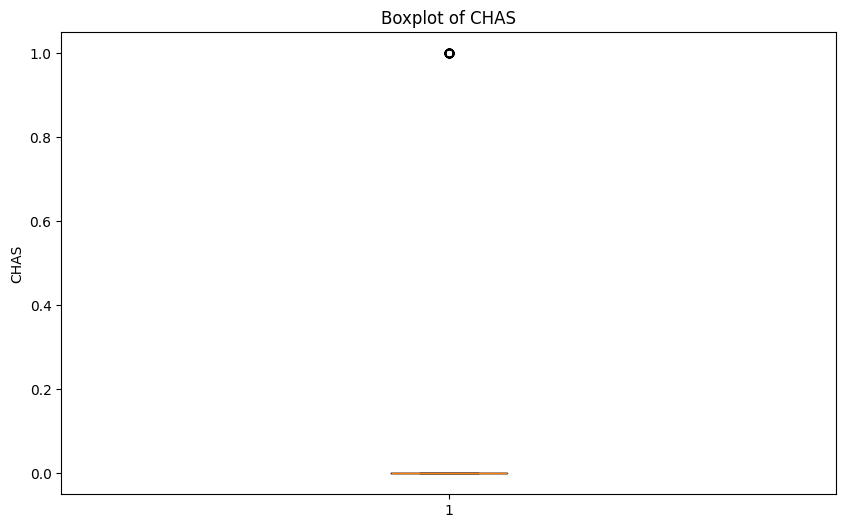

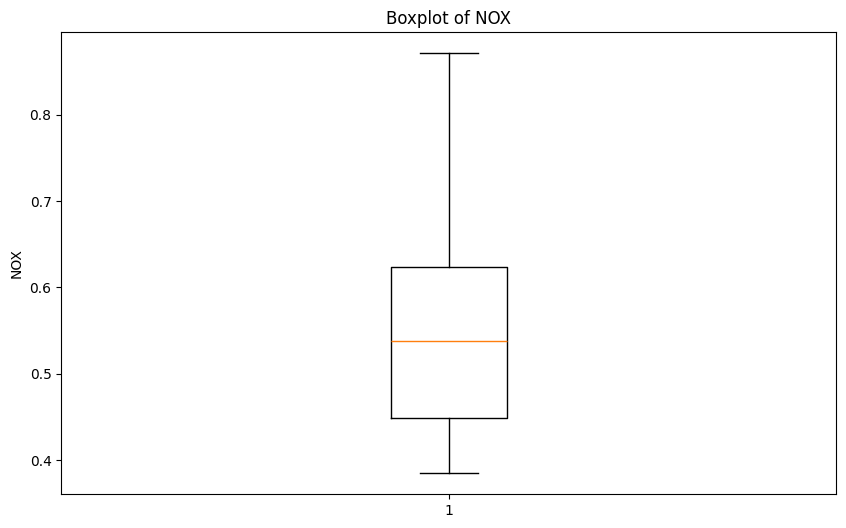

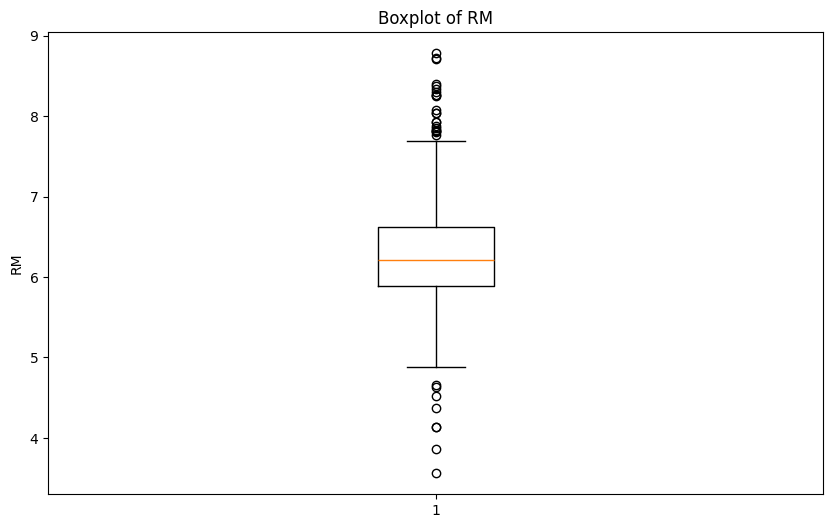

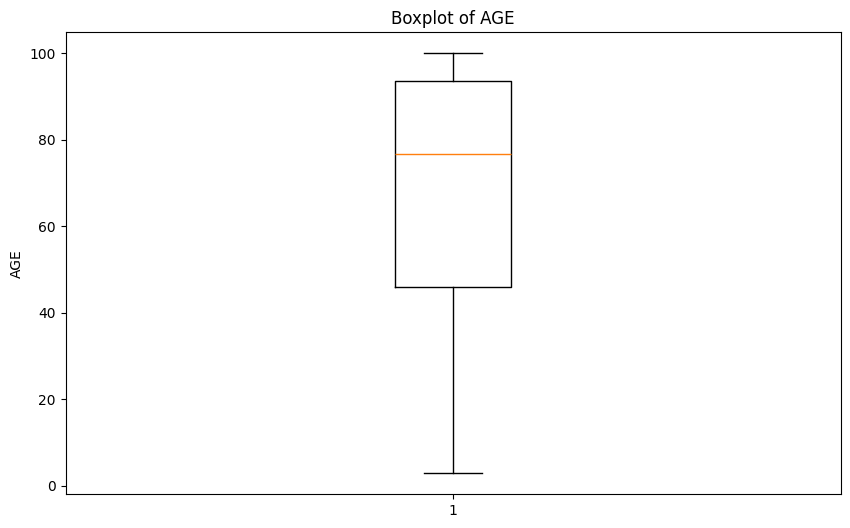

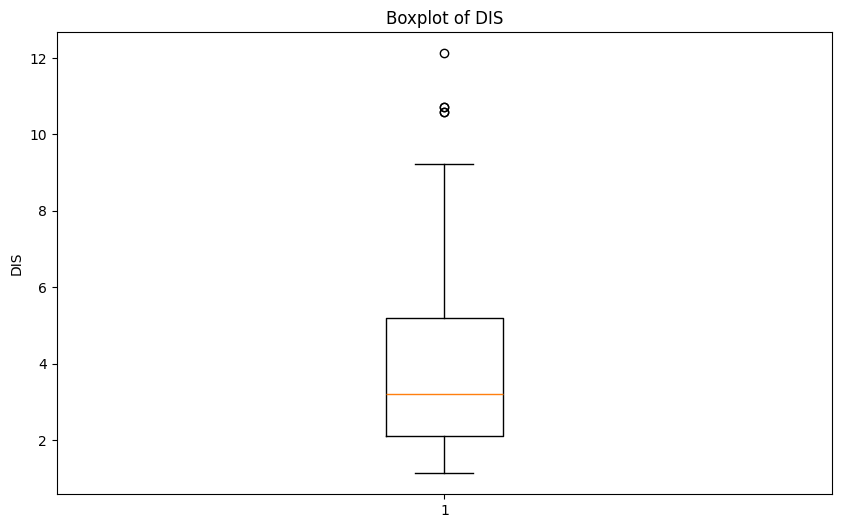

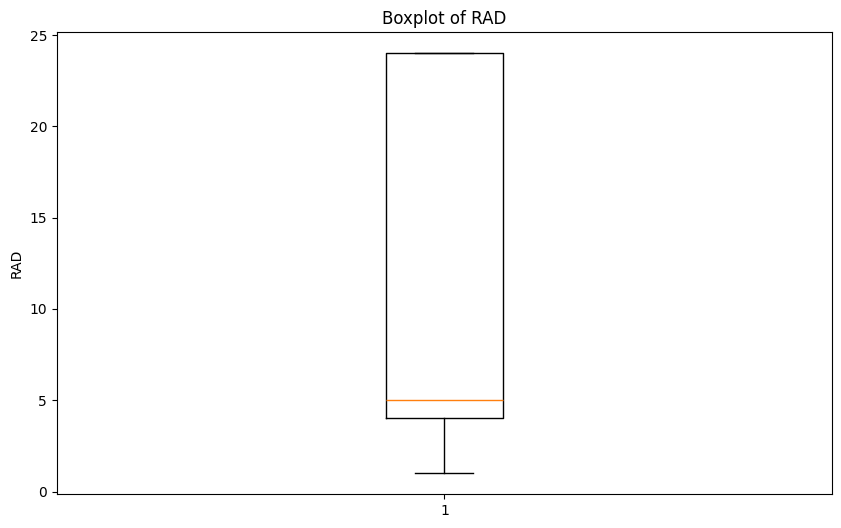

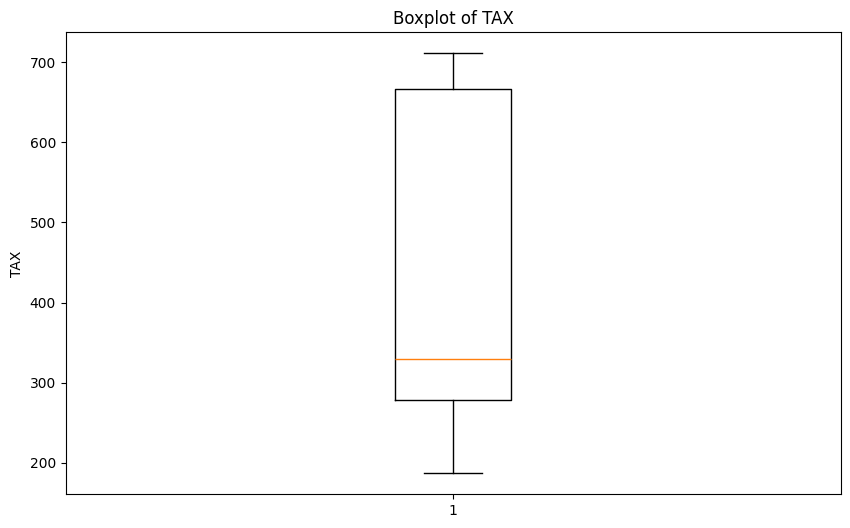

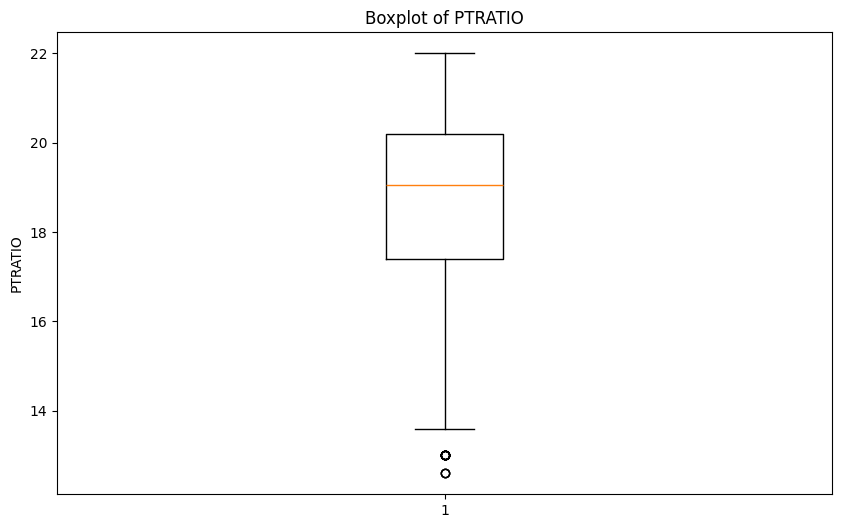

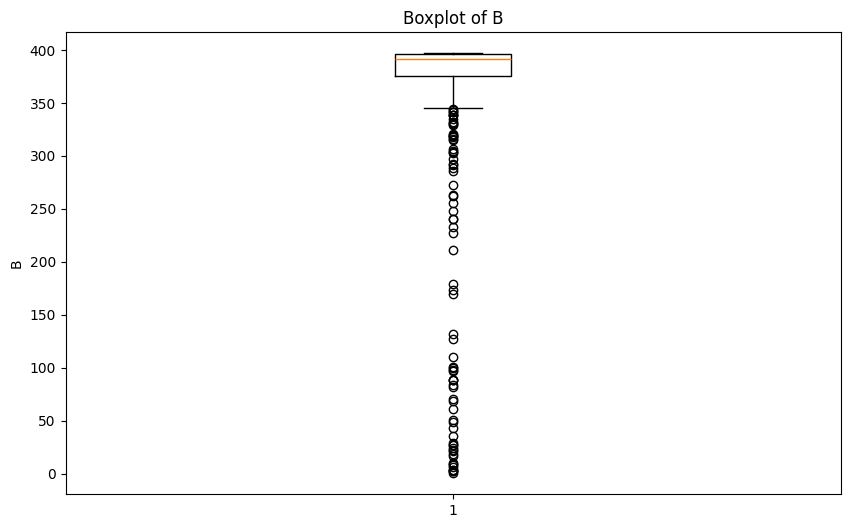

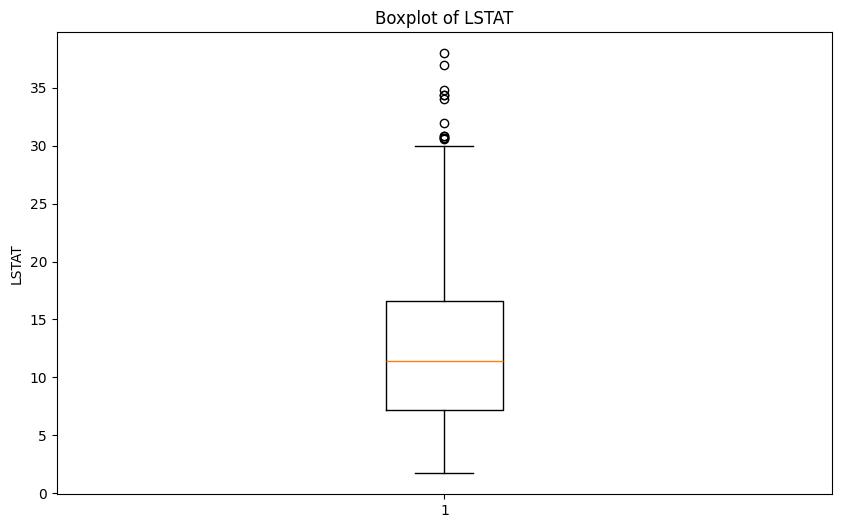

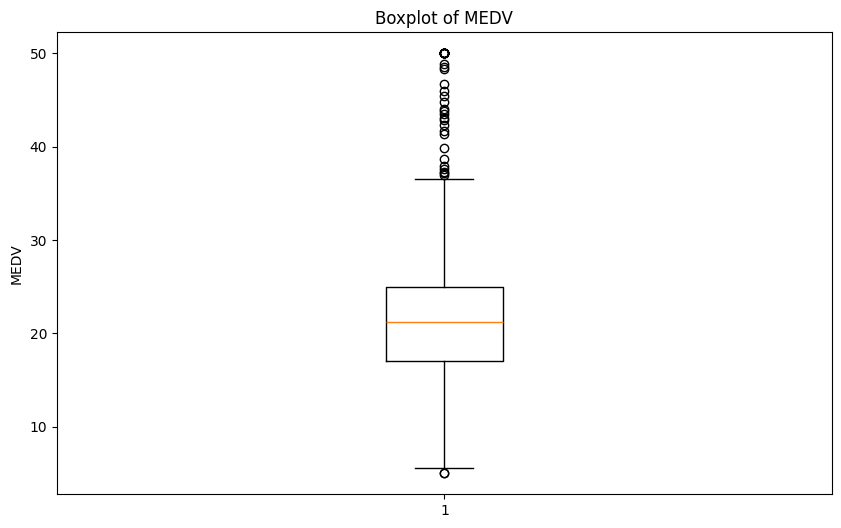

In [70]:
import matplotlib.pyplot as plt

columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
           'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

for col in columns:
    plt.figure(figsize=(10, 6))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

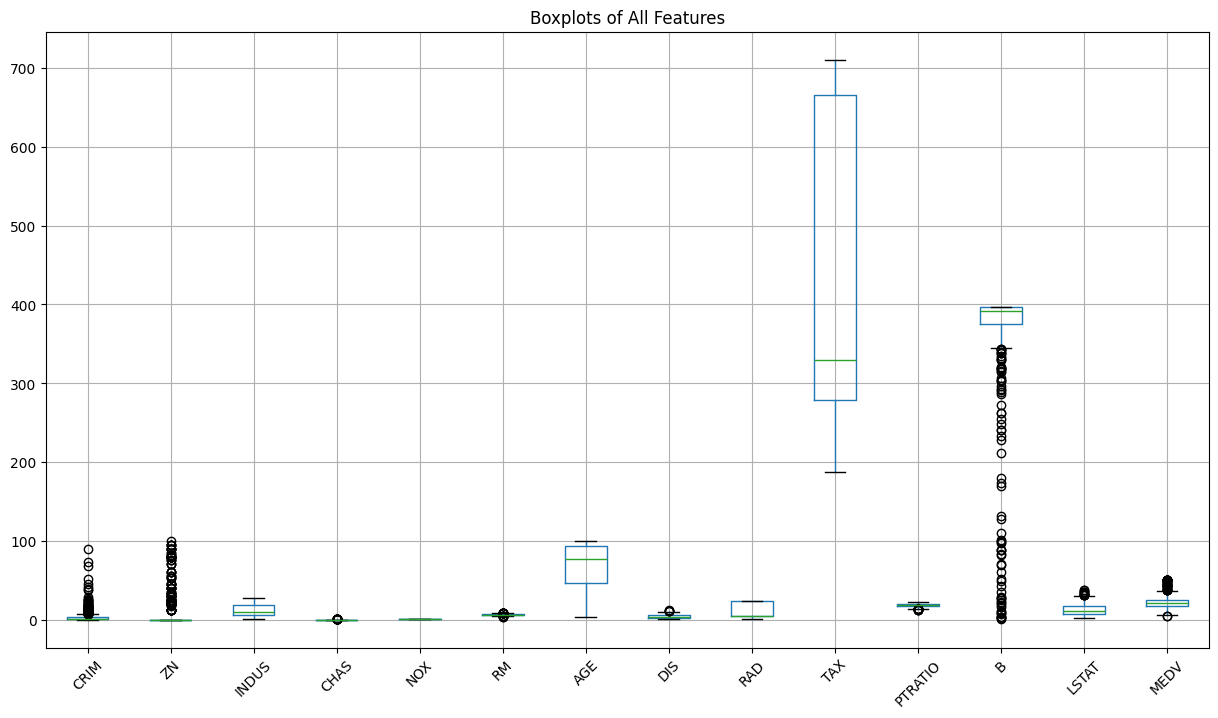

In [75]:
plt.figure(figsize=(15, 8))
df[columns].boxplot(rot=45)
plt.title("Boxplots of All Features")
plt.show()

In [76]:
df['RM_PER_TAX'] = df['RM'] / (df['TAX'] + 1)

In [77]:
df['CRIM_PER_ROOM'] = df['CRIM'] / (df['RM'] + 1)

In [78]:
df['RAD_TAX_RATIO'] = df['RAD'] / (df['TAX'] + 1)

In [79]:
df['NOX_CRIM'] = df['NOX'] * df['CRIM']

In [80]:
df['RM_LSTAT'] = df['RM'] * df['LSTAT']

In [81]:
df['AGE_CATEGORY'] = pd.cut(
    df['AGE'],
    bins=[0, 35, 70, 100],
    labels=['New', 'Medium', 'Old']
)

In [82]:
import numpy as np

df['CRIM'] = np.log1p(df['CRIM'])
df['LSTAT'] = np.log1p(df['LSTAT'])

In [83]:
df['RM_NOX'] = df['RM'] * df['NOX']

df['DIS_AGE'] = df['DIS'] * df['AGE']

In [84]:
df.drop(
    columns=[
        'RM_LSTAT',
        'NOX_CRIM',
        'RAD_TAX_RATIO'
    ],
    inplace=True
)

In [87]:
import numpy as np

# Calculate skewness only for numeric columns to avoid TypeError with categorical data
df.select_dtypes(include=np.number).skew()

,0
CRIM,1.363098
ZN,2.324603
INDUS,0.333501
CHAS,3.467800
NOX,0.729308
RM,0.403612
AGE,-0.625968
DIS,1.011781
RAD,1.004815
TAX,0.669956


In [91]:
from sklearn.model_selection import train_test_split

In [96]:
import pandas as pd

# Convert categorical 'AGE_CATEGORY' into numerical dummy variables
df_final = pd.get_dummies(df, columns=['AGE_CATEGORY'], drop_first=True)

X = df_final.drop("MEDV", axis=1)
y = df_final["MEDV"]

In [88]:
from sklearn.model_selection import train_test_split

In [106]:
X = df_final.drop("MEDV", axis=1)
y = df_final["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [98]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# Verify training
print("Model trained successfully!")
print(f"R^2 Score on training set: {lr.score(X_train, y_train):.4f}")

Model trained successfully!
R^2 Score on training set: 0.7976


In [107]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Retrain Linear Regression on correct data
lr.fit(X_train, y_train)

# Train Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Evaluation
def evaluate(model, name):
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name} - Test MSE: {mse:.4f}, Test R2: {r2:.4f}")

evaluate(lr, "Linear Regression")
evaluate(dt, "Decision Tree")

Linear Regression - Test MSE: 18.4882, Test R2: 0.7479
Decision Tree - Test MSE: 12.8797, Test R2: 0.8244


In [108]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate Linear Regression
lr_preds = lr.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

# Evaluate Decision Tree
dt_preds = dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

print("--- Model Evaluation (Test Set) ---")
print(f"Linear Regression: MSE = {lr_mse:.4f}, R2 = {lr_r2:.4f}")
print(f"Decision Tree:     MSE = {dt_mse:.4f}, R2 = {dt_r2:.4f}")

--- Model Evaluation (Test Set) ---
Linear Regression: MSE = 18.4882, R2 = 0.7479
Decision Tree:     MSE = 12.8797, R2 = 0.8244


In [100]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [101]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [102]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()

knn.fit(X_train,y_train)

KNeighborsRegressor()

In [103]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train,y_train)

SVR()

In [104]:
y_pred = xgb.predict(X_test)

In [105]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

2.01495792538512
7.550861844663708
2.747883157025369
0.8970343337100727


In [109]:
y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 2.829182581907505
MSE : 18.488239408928163
RMSE: 4.299795275234411
R2 : 0.7478891908725203


In [112]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "KNN": knn,
    "SVR": svr
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results.append({"Model": name, "MSE": mse, "R2 Score": r2})

# Create a comparison dataframe and sort by R2 Score
comparison_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("Overall Model Comparison (Test Set):")
display(comparison_df)

Overall Model Comparison (Test Set):


,Model,MSE,R2 Score
3,XGBoost,7.550862,0.897034
2,Random Forest,7.887866,0.892439
1,Decision Tree,12.879706,0.824369
0,Linear Regression,18.488239,0.747889
4,KNN,23.689463,0.676964
5,SVR,52.096397,0.289599


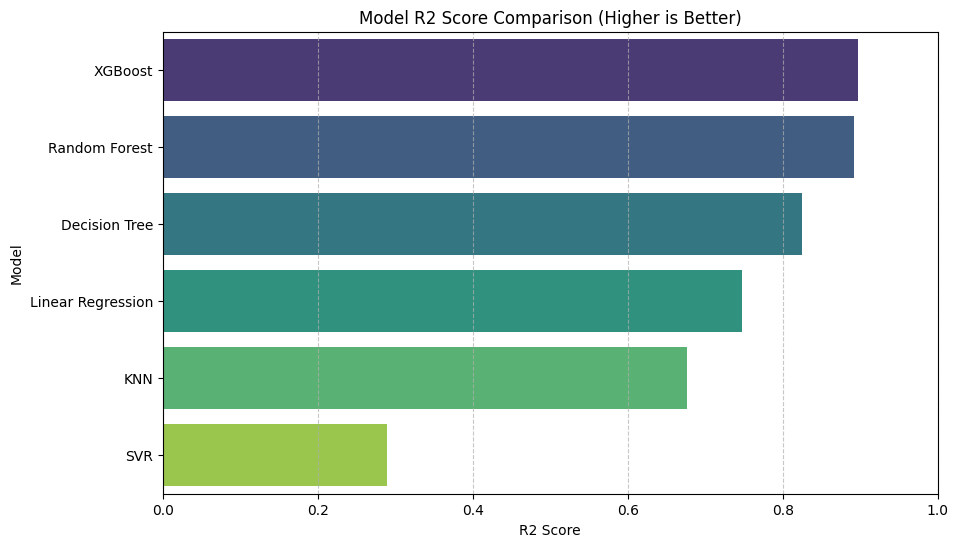

Summary: The best model is XGBoost with a Test R2 score of 0.8970.


In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize model performance comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="R2 Score", y="Model", data=comparison_df, hue="Model", palette="viridis", legend=False)
plt.title("Model R2 Score Comparison (Higher is Better)")
plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# Print final summary
best_model = comparison_df.iloc[0]["Model"]
best_r2 = comparison_df.iloc[0]["R2 Score"]
print(f"Summary: The best model is {best_model} with a Test R2 score of {best_r2:.4f}.")

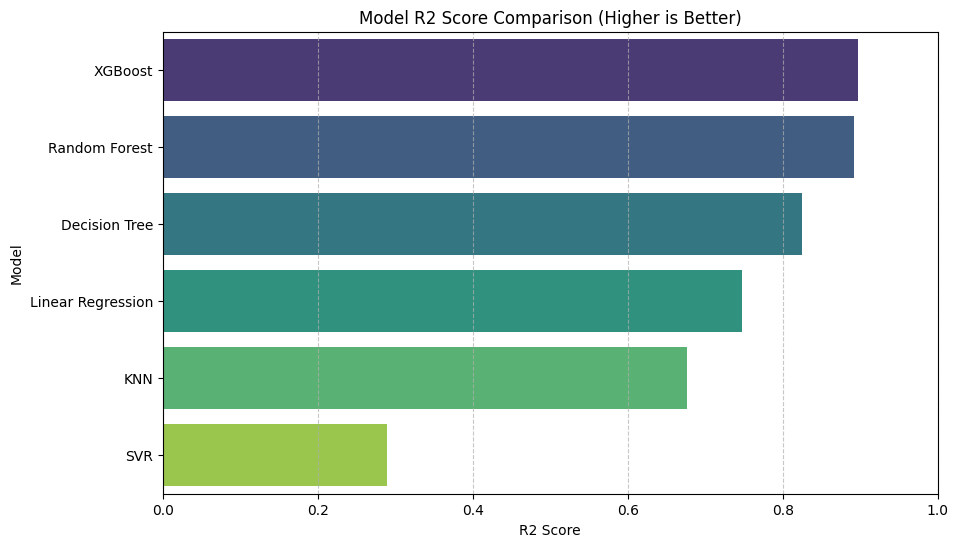

Summary: The best model is XGBoost with a Test R2 score of 0.8970.


In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize model performance comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='R2 Score', y='Model', data=comparison_df, hue='Model', palette='viridis', legend=False)
plt.title('Model R2 Score Comparison (Higher is Better)')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Print final summary
best_model = comparison_df.iloc[0]['Model']
best_r2 = comparison_df.iloc[0]['R2 Score']
print(f"Summary: The best model is {best_model} with a Test R2 score of {best_r2:.4f}.")

/tmp/ipykernel_1093/168342401.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=comparison_df, palette='viridis')


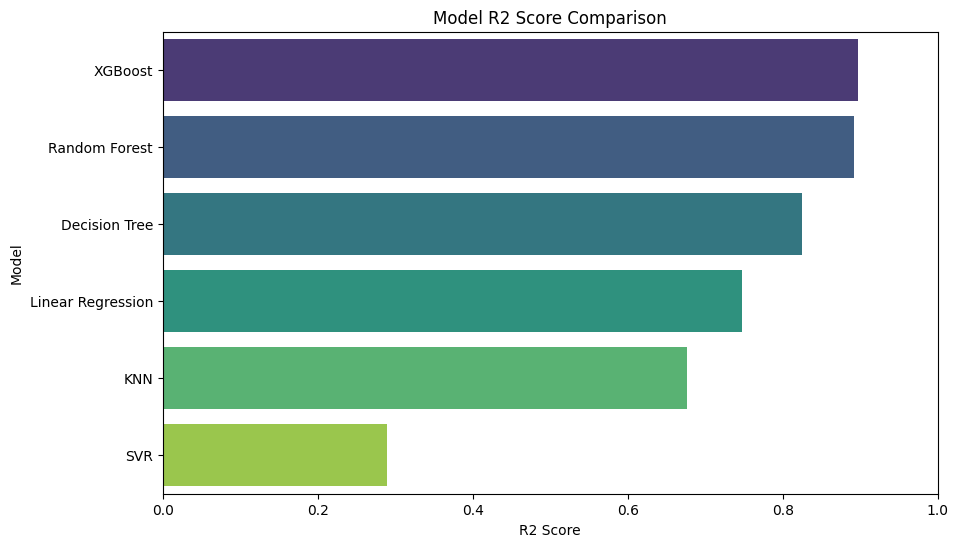

Summary:
The best model is XGBoost with an R2 of 0.8970.


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='R2 Score', y='Model', data=comparison_df, palette='viridis')
plt.title('Model R2 Score Comparison')
plt.xlim(0, 1)
plt.show()

print("Summary:")
print(f"The best model is {comparison_df.iloc[0]['Model']} with an R2 of {comparison_df.iloc[0]['R2 Score']:.4f}.")

In [116]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': [100,200,300,500],
    'max_depth': [3,4,5,6,8],
    'learning_rate': [0.01,0.05,0.1,0.2],
    'subsample': [0.8,0.9,1.0],
    'colsample_bytree': [0.8,0.9,1.0],
    'gamma': [0,0.1,0.3,0.5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [117]:
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.9}


In [118]:
print(random_search.best_score_)

0.8414998315523501


In [119]:
best_model = random_search.best_estimator_

In [120]:
y_pred = best_model.predict(X_test)

In [121]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 1.9299707739960914
MSE : 6.974569146598803
RMSE : 2.640940958559809
R2 : 0.9048928222978632


<Figure size 1000x600 with 0 Axes>

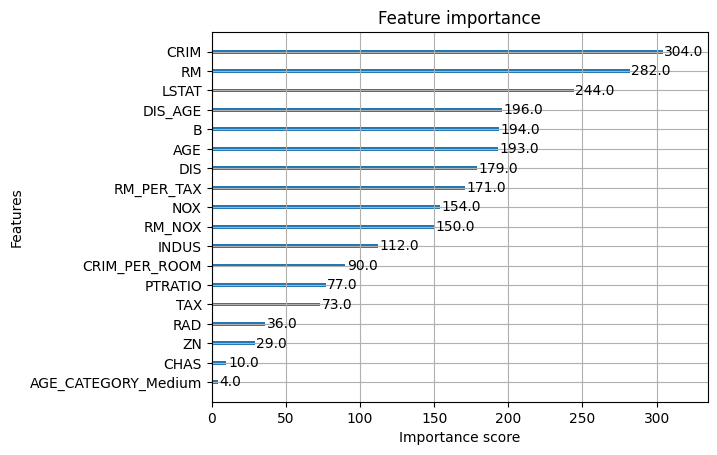

In [122]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plot_importance(best_model)

plt.show()

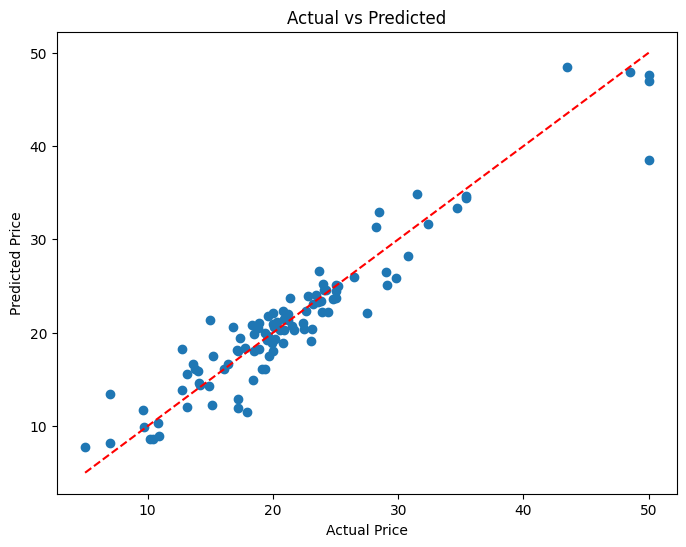

In [123]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

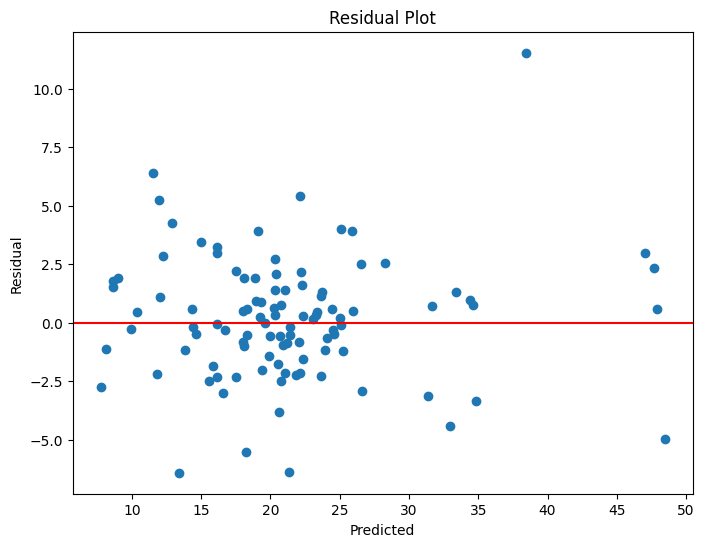

In [124]:
residuals = y_test-y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred,residuals)

plt.axhline(0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [125]:
import joblib

joblib.dump(best_model,"house_price_model.joblib")

['house_price_model.joblib']